# Dataset Exploration & Validation

## tujuan notebook
notebook ini melakukan eksplorasi dan validasi dataset yang akan digunakan di proyek:
- menganalisis karakteristik dataset sentiment (amazon_polarity, yelp_review_full, imdb)
- menganalisis karakteristik dataset summarization (cnn_dailymail)
- mengukur distribusi panjang token untuk membuktikan kebutuhan chunking
- memvalidasi distribusi label untuk justifikasi pemilihan dataset baseline
- **visualisasi distribusi** untuk insight yang lebih jelas
- **tidak melakukan preprocessing atau training** - hanya analisis eksploratif

## input yang dibutuhkan
- **dataset (download otomatis via HuggingFace)**:
  - `amazon_polarity` (untuk analisis baseline)
  - `yelp_review_full` (untuk analisis long-text)
  - `imdb` (untuk analisis long-text)
  - `cnn_dailymail` v3.0.0 (untuk analisis summarization)
- **model tokenizer**: `distilbert-base-uncased` (untuk analisis panjang token)
- **persyaratan**:
  - akses internet untuk download dataset
  - environment sudah disetup (notebook 00)

**catatan**: dataset di-load dengan **random sampling** (seed=42) untuk distribusi label yang representatif.

## output yang dihasilkan
- **visualisasi distribusi panjang token** (histogram untuk setiap dataset)
- **visualisasi distribusi label** (bar chart untuk dataset sentiment)
- **statistik panjang token** untuk setiap dataset:
  - min, mean, max, p95
  - persentase teks > 512 token (bukti kebutuhan chunking)
- **distribusi label** untuk dataset sentiment (dengan persentase)
- **contoh data mentah** untuk inspeksi manual
- **insight**: Justifikasi teknis mengapa chunking dan pipeline terpisah diperlukan

## dependencies dari notebook lain
- **menggunakan**:
  - environment setup dari notebook 00 (helper functions, direktori)
- **digunakan oleh**:
  - notebook 02 (justifikasi pemilihan amazon_polarity sebagai baseline)
  - notebook 03 (justifikasi kebutuhan chunking untuk long-text)
  - notebook 04 (justifikasi pemilihan cnn_dailymail untuk summarization)

## urutan eksekusi
jalankan setelah notebook 00, sebelum notebook 02-04.

### Import & Konfigurasi Dasar

In [12]:
from datasets import load_dataset
import numpy as np
from transformers import AutoTokenizer

### Load Dataset

In [13]:
# subset kecil (eksplorasi cepat)
# subset dengan random sampling untuk distribusi label yang seimbang
# dataset full dipakai saat training (bukan bagian)
datasets_cfg = {
    "amazon": load_dataset("amazon_polarity", split="train").shuffle(seed=42).select(range(int(3.6e6 * 0.05))),  # 5% dari 3.6M
    "yelp": load_dataset("yelp_review_full", split="train").shuffle(seed=42).select(range(int(650_000 * 0.05))),  # 5% dari 650K
    "imdb": load_dataset("imdb", split="train").shuffle(seed=42).select(range(int(25_000 * 0.05))),  # 5% dari 25K
    "cnn_dm": load_dataset("cnn_dailymail", "3.0.0", split="train").shuffle(seed=42).select(range(int(287_113 * 0.05)))  # 5% dari 287K
}


### Tokenizer Baseline

In [14]:
# tokenizer sesuai model sentiment (analisis panjang saja)
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

### Visualisasi Distribusi Panjang Token

- visualisasi distribusi panjang token untuk setiap dataset
- membuktikan kebutuhan chunking secara visual

In [15]:
!pip install -q matplotlib seaborn

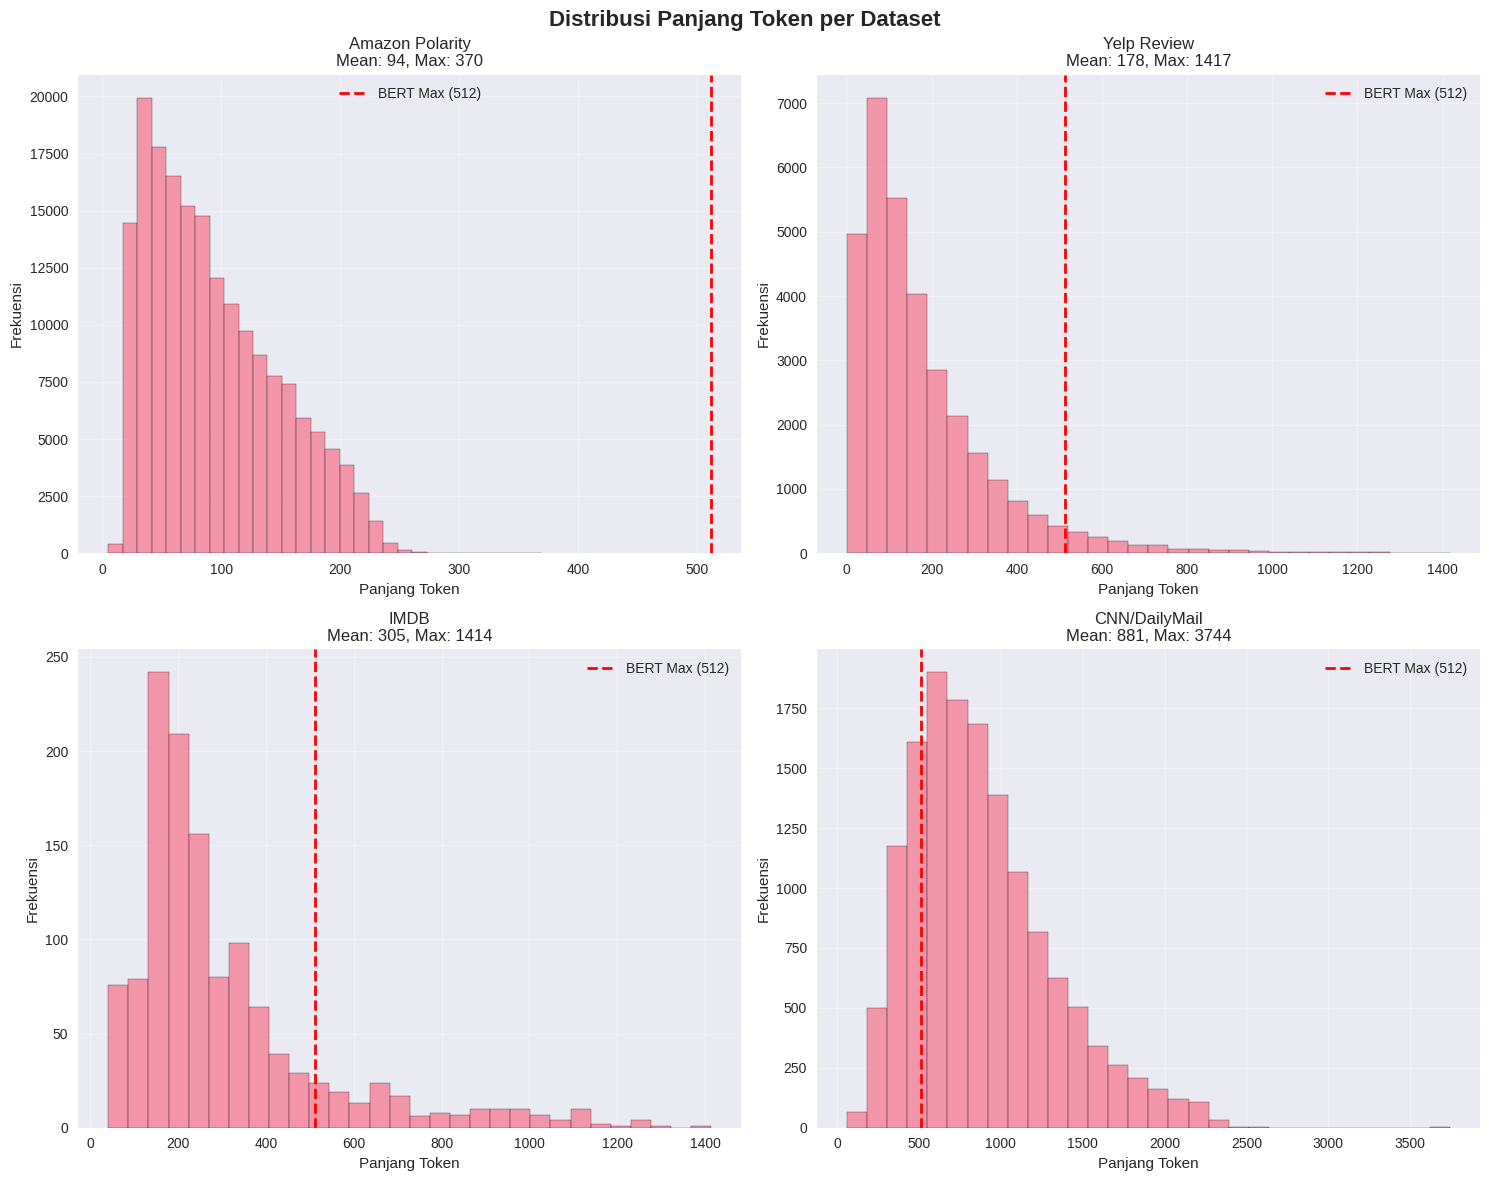


STATISTIK PANJANG TOKEN

Amazon Polarity:
  Mean: 94 tokens
  P95: 198 tokens
  Max: 370 tokens
  % > 512: 0.00%

Yelp Review:
  Mean: 178 tokens
  P95: 492 tokens
  Max: 1417 tokens
  % > 512: 4.46%

IMDB:
  Mean: 305 tokens
  P95: 843 tokens
  Max: 1414 tokens
  % > 512: 13.20%

CNN/DailyMail:
  Mean: 881 tokens
  P95: 1734 tokens
  Max: 3744 tokens
  % > 512: 80.38%


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from transformers import logging as transformers_logging

# setup style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# suppress warnings (expected karena kita sengaja mengukur panjang asli)
transformers_logging.set_verbosity_error()

def visualize_length_distribution(datasets_cfg, tokenizer):
    """visualisasi distribusi panjang token untuk semua dataset."""

    datasets_info = [
        ("amazon", "content", "Amazon Polarity"),
        ("yelp", "text", "Yelp Review"),
        ("imdb", "text", "IMDB"),
        ("cnn_dm", "article", "CNN/DailyMail")
    ]

    # hitung panjang token SEKALI untuk semua dataset
    all_lengths = {}
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        for dataset_key, text_key, title in datasets_info:
            all_lengths[dataset_key] = [
                len(tokenizer(d[text_key], truncation=False, add_special_tokens=False)["input_ids"])
                for d in datasets_cfg[dataset_key]
            ]

    # visualisasi
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Distribusi Panjang Token per Dataset', fontsize=16, fontweight='bold')

    for idx, (dataset_key, text_key, title) in enumerate(datasets_info):
        ax = axes[idx // 2, idx % 2]
        lengths = all_lengths[dataset_key]

        # plot histogram
        ax.hist(lengths, bins=30, alpha=0.7, edgecolor='black')  # Kurangi bins untuk lebih cepat
        ax.axvline(x=512, color='r', linestyle='--', linewidth=2, label='BERT Max (512)')
        ax.set_xlabel('Panjang Token', fontsize=11)
        ax.set_ylabel('Frekuensi', fontsize=11)
        ax.set_title(f'{title}\nMean: {np.mean(lengths):.0f}, Max: {max(lengths)}', fontsize=12)
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # print statistik (gunakan data yang sudah dihitung)
    print("\n" + "="*60)
    print("STATISTIK PANJANG TOKEN")
    print("="*60)
    for dataset_key, text_key, title in datasets_info:
        lengths = all_lengths[dataset_key]
        pct_above_512 = sum(l > 512 for l in lengths) / len(lengths) * 100
        print(f"\n{title}:")
        print(f"  Mean: {np.mean(lengths):.0f} tokens")
        print(f"  P95: {np.percentile(lengths, 95):.0f} tokens")
        print(f"  Max: {max(lengths)} tokens")
        print(f"  % > 512: {pct_above_512:.2f}%")

    # restore logging
    transformers_logging.set_verbosity_warning()

# jalankan visualisasi
visualize_length_distribution(datasets_cfg, tokenizer)

### Fungsi Analisis Panjang Teks

In [17]:
def analyze_lengths(dataset, text_key):
    # mengukur distribusi panjang token TANPA truncation
    lengths = [
        len(
            tokenizer(
                d[text_key],
                truncation=False,
                add_special_tokens=False # CLS/SEP tidak relevan untuk statistik panjang ( statistik murni panjang konten )
            )["input_ids"]
        )
        for d in dataset
    ]

    return {
        "min": int(np.min(lengths)),
        "mean": int(np.mean(lengths)),
        "max": int(np.max(lengths)),
        "p95": int(np.percentile(lengths, 95)),
        "pct_above_512": round(
            sum(l > 512 for l in lengths) / len(lengths) * 100, 2 # bukti eksplisit chunking wajib
        )
    }


### Analisis Dataset Sentiment

In [18]:
# amazon: short text (baseline fine-tuning)
# yelp & IMDB: long text (butuh chunking)
amazon_stats = analyze_lengths(datasets_cfg["amazon"], "content")
yelp_stats   = analyze_lengths(datasets_cfg["yelp"], "text")
imdb_stats   = analyze_lengths(datasets_cfg["imdb"], "text")

amazon_stats, yelp_stats, imdb_stats

({'min': 5, 'mean': 93, 'max': 370, 'p95': 198, 'pct_above_512': 0.0},
 {'min': 1, 'mean': 178, 'max': 1417, 'p95': 492, 'pct_above_512': 4.46},
 {'min': 41, 'mean': 304, 'max': 1414, 'p95': 842, 'pct_above_512': 13.2})

### Analisis Dataset Summarization

In [19]:
# artikel panjang
# tidak bisa langsung masuk sentiment model
cnn_stats = analyze_lengths(datasets_cfg["cnn_dm"], "article")
cnn_stats

{'min': 59, 'mean': 881, 'max': 3744, 'p95': 1733, 'pct_above_512': 80.38}

### Cek Distribusi Label (Sentiment)

In [20]:
from collections import Counter

# validasi distribusi label (harus relatif seimbang)
# justifikasi pemakaian amazon_polarity sebagai dataset baseline
Counter(datasets_cfg["amazon"]["label"])

Counter({0: 90300, 1: 89700})

### Visualisasi Distribusi Label

- memvalidasi keseimbangan dataset sentiment

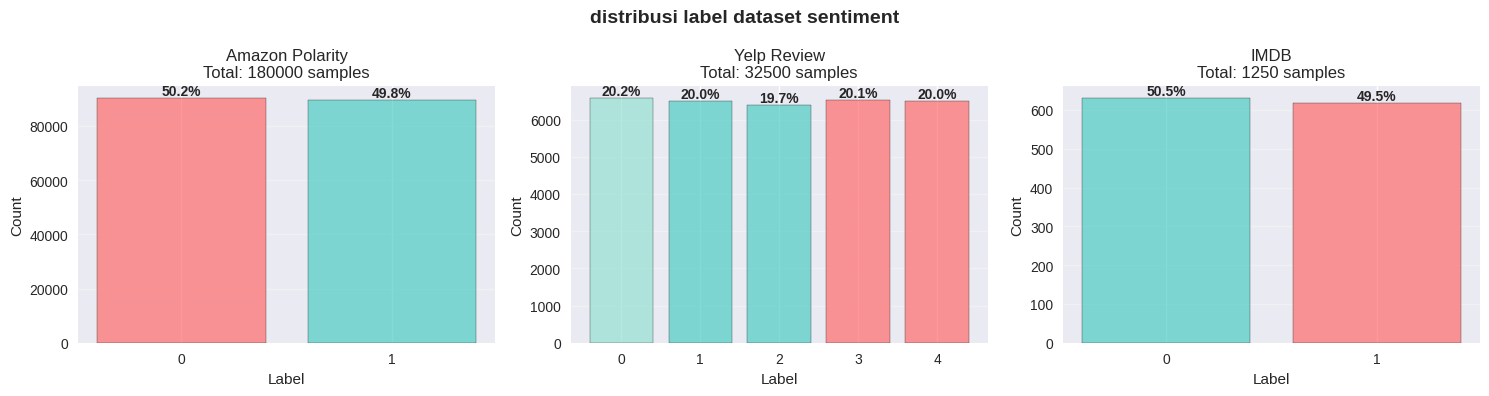

In [21]:
# visualisasi distribusi label untuk dataset sentiment
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('distribusi label dataset sentiment', fontsize=14, fontweight='bold')

datasets_label = [
    ("amazon", "Amazon Polarity", axes[0]),
    ("yelp", "Yelp Review", axes[1]),
    ("imdb", "IMDB", axes[2])
]

for dataset_key, title, ax in datasets_label:
    labels = datasets_cfg[dataset_key]["label"]
    label_counts = Counter(labels)

    # bar plot
    labels_list = list(label_counts.keys())
    counts_list = list(label_counts.values())
    colors = ['#ff6b6b', '#4ecdc4'] if len(labels_list) == 2 else ['#ff6b6b', '#4ecdc4', '#95e1d3']

    ax.bar(labels_list, counts_list, color=colors[:len(labels_list)], alpha=0.7, edgecolor='black')
    ax.set_xlabel('Label', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title(f'{title}\nTotal: {sum(counts_list)} samples', fontsize=12)
    ax.set_xticks(labels_list)
    ax.grid(True, alpha=0.3, axis='y')

    # tambahkan persentase
    for i, (label, count) in enumerate(label_counts.items()):
        pct = count / sum(counts_list) * 100
        ax.text(label, count, f'{pct:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

### Contoh Data Mentah

In [22]:
# dipakai untuk inspeksi manual dan sanity check
print("AMAZON SAMPLE:\n", datasets_cfg["amazon"][0]["content"][:500])
print("\nIMDB SAMPLE:\n", datasets_cfg["imdb"][0]["text"][:500])

AMAZON SAMPLE:
 All the pretty people in this film. Even the Rudy character played by Michael Madsen. This is adapted from a Jim Thompson novel for cryin' out loud! These are supposed to be marginal characters, not fashion models. Though McQueen and McGraw were attractive (but check out McQueen's crummy prison haircut) they were believable in the role. Baldwin and Bassinger seem like movie stars trying to act like hard cases. Action wise, the robbery scene in the Pekinpah version was about 100 times more exciti

IMDB SAMPLE:
 There is no relation at all between Fortier and Profiler but the fact that both are police series about violent crimes. Profiler looks crispy, Fortier looks classic. Profiler plots are quite simple. Fortier's plot are far more complicated... Fortier looks more like Prime Suspect, if we have to spot similarities... The main character is weak and weirdo, but have "clairvoyance". People like to compare, to judge, to evaluate. How about just enjoying? Funny thing too,